# Demo

This demo walks through:
1. Making a layer/gate set for an IBM device.
2. Creating a 2-local Pauli-Lindblad model based on the device topology.
3. Build "vanilla" Pauli-Lindblad learning experiments.
4. Running the experiments.
5. Fitting the model and getting noise maps.

In [1]:
from qiskit_ibm_runtime import Executor, QiskitRuntimeService

runtime = QiskitRuntimeService(name="foo")
backend = runtime.backend("ibm_marrakesh")
executor = Executor(backend)

qiskit_runtime_service.__init__:WARNING:2026-05-11 16:04:28,443: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (internal, premium), the available account instances are: engine-premium-eu, engine-internal-eu, engine-internal-us, engine-premium-us. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-11 16:04:28,445: Using instance: engine-premium-us, plan: premium


## 1. Build a gate set with a single layer on a ring of qubits

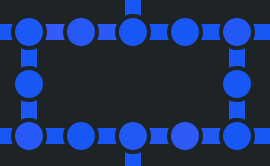

In [2]:
from qiskit_noise_learning.gate_sets import QiskitGateSet

qubit_subset = [*range(25, 30), *range(37, 39), *range(45, 50)]
gate_set = QiskitGateSet(backend.num_qubits, target=backend.target, qubit_subset=qubit_subset)

layer_1_pairs = [(25, 26), (27, 28), (29, 38), (37, 45), (46, 47), (48, 49)]

with gate_set.build_new_gate("layer_1") as builder:
    for pair in layer_1_pairs:
        builder.circuit.cz(*pair)

In [3]:
gate_set.draw()

## 2. Create a 2-local Pauli-Lindblad model.

In [4]:
from qiskit_noise_learning.models import PauliLindbladModel

pauli_lindblad_model = PauliLindbladModel.k_local(gate_set, k=2)

## 3. Build learning experiments

In [5]:
from qiskit_noise_learning.experiment_builder import (
    ExperimentBuilder,
    standard_vanilla_pattern_generator,
)

experiment_builder = ExperimentBuilder(fidelity_model=pauli_lindblad_model)

experiment_builder.add_path_patterns(
    standard_vanilla_pattern_generator(
        experiment_builder.gate_set["P"],
        experiment_builder.gate_set["M"],
        experiment_builder.gate_set["layer_1"],
        pauli_lindblad_model.generators["layer_1"],
        experiment_builder.gate_set.coupling_map,
    ),
    attempt_instruction_merge=True,
)
experiment_builder.complete()

print(f"Number of path patterns: {len(experiment_builder.path_patterns)}")
print(f"Number of instruction patterns: {len(experiment_builder.instruction_patterns)}")

Number of path patterns: 108
Number of instruction patterns: 9


## 4. Run experiments

In [6]:
# generate instruction sequences
depths = [0, 2, 16, 32, 64, 128]
instruction_sequences = experiment_builder.generate_instruction_sequences(depths)

print(f"Number of instruction sequences: {len(instruction_sequences)}")

Number of instruction sequences: 54


Number of template circuits: 6
Depth 2 template circuit:


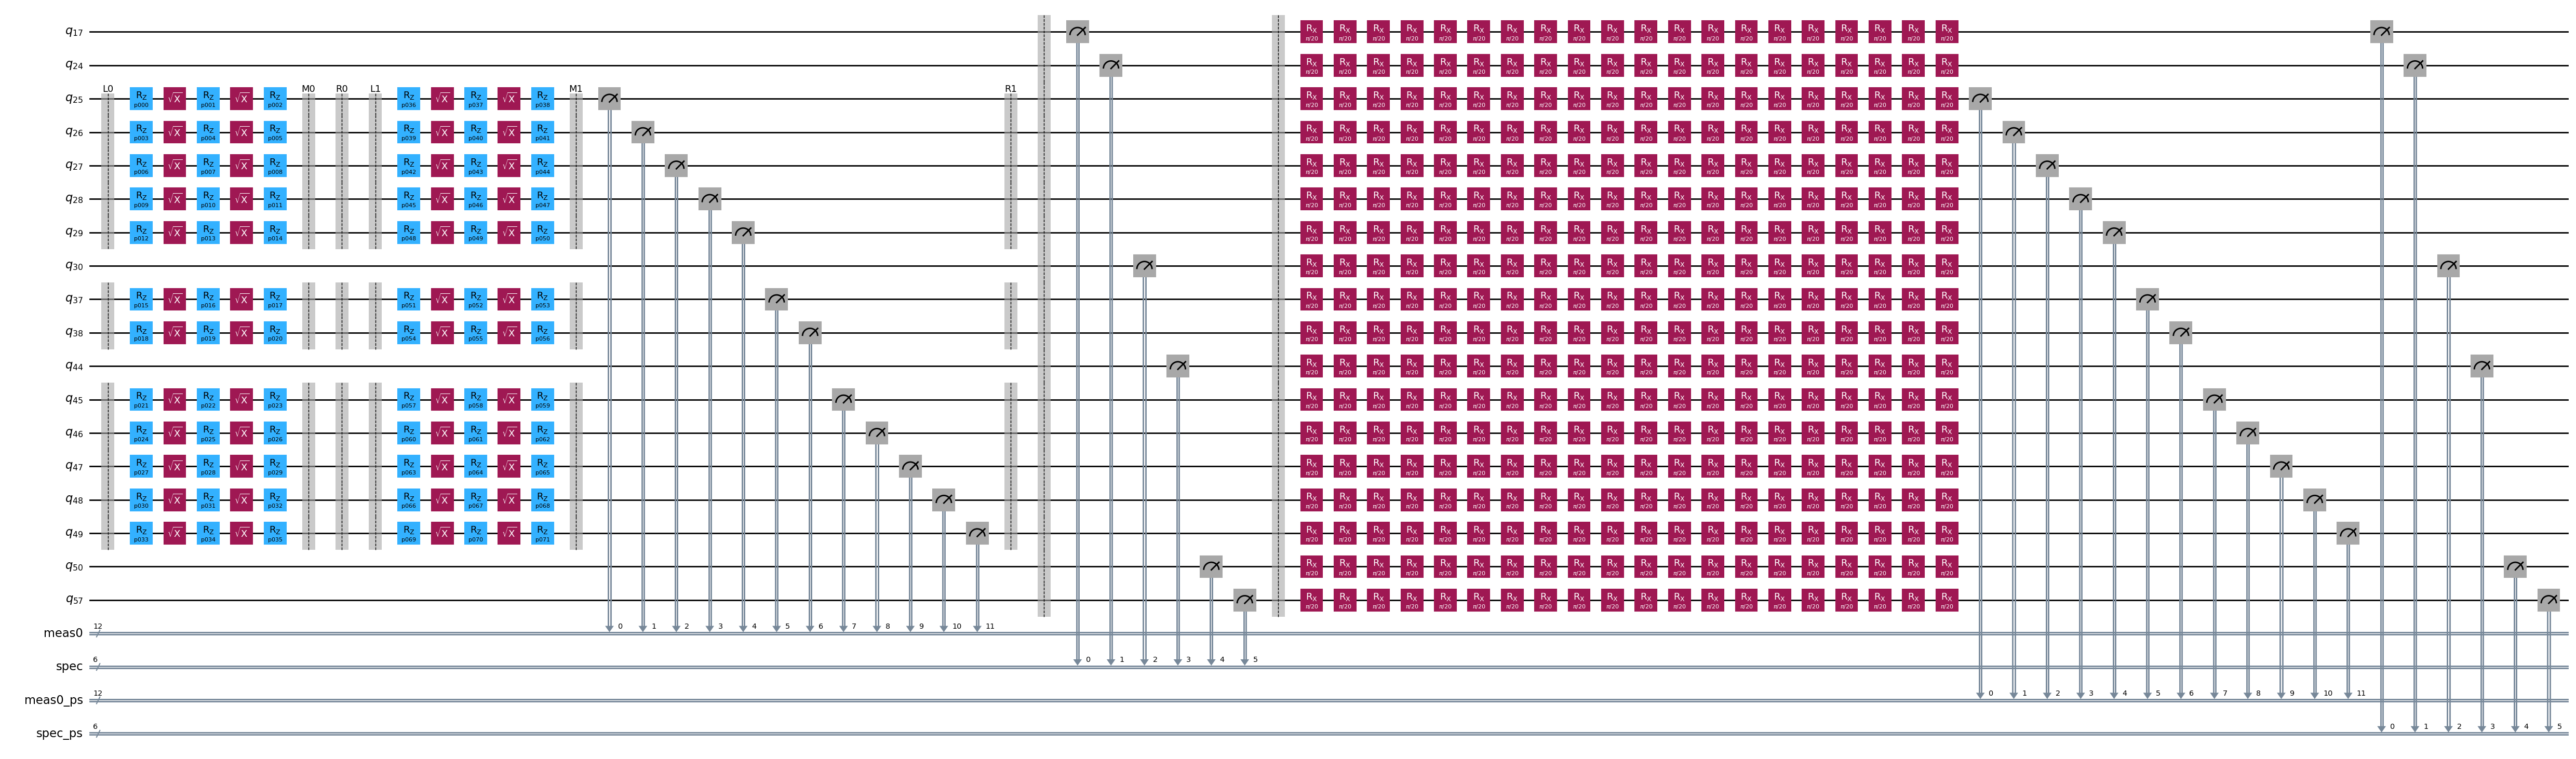

In [7]:
from qiskit.transpiler import PassManager
from qiskit_addon_utils.noise_management.post_selection.transpiler.passes import (
    AddPostSelectionMeasures,
    AddSpectatorMeasures,
)

from qiskit_noise_learning.circuit_generator import ExecutorCircuitGenerator

# build post selection pass manager
post_selection_pm = PassManager(
    [
        AddSpectatorMeasures(backend.coupling_map),
        AddPostSelectionMeasures(x_pulse_type="rx"),
    ]
)

# generate inputs to executor
num_rand = 50
circuit_generator = ExecutorCircuitGenerator(
    gate_set, num_randomizations=num_rand, pass_manager=post_selection_pm
)
samplex_items, data_mapper = circuit_generator.generate(instruction_sequences)

print(f"Number of template circuits: {len(samplex_items)}")
print("Depth 2 template circuit:")
samplex_items[0].circuit.draw("mpl", idle_wires=False, fold=False)

In [8]:
# run program and collect raw data
from qiskit_ibm_runtime import QuantumProgram

num_shots = 20
qp = QuantumProgram(num_shots, samplex_items)
# job = executor.run(qp)
job = runtime.job("d7v7ao3ack5s73bf2tlg")  # previous job
raw_data = circuit_generator.collect(job.result(), data_mapper)

## 5. Analyzing the data

In [9]:
from qiskit_noise_learning.analysis import (
    ComputeObservables,
    CurveFitObservables,
    FlipPostSelect,
    NNLSSolve,
)

analyzer = FlipPostSelect() + ComputeObservables() + CurveFitObservables() + NNLSSolve()

In [10]:
from qiskit_noise_learning.analysis import Fit
from qiskit_noise_learning.data import RawData
from qiskit_noise_learning.sequences import Path

fit = Fit(
    model=pauli_lindblad_model,
    paths=[Path(p, d) for p in experiment_builder.path_patterns for d in depths],
)
fit[RawData] = raw_data

In [11]:
fit = analyzer.run(fit)

Check percentage of shots removed by post-selection.

In [19]:
fit.raw_data.datatree["0"]["data_mask"].mean()

<xarray.DataArray 'data_mask' ()> Size: 8B
array(0.18505556)

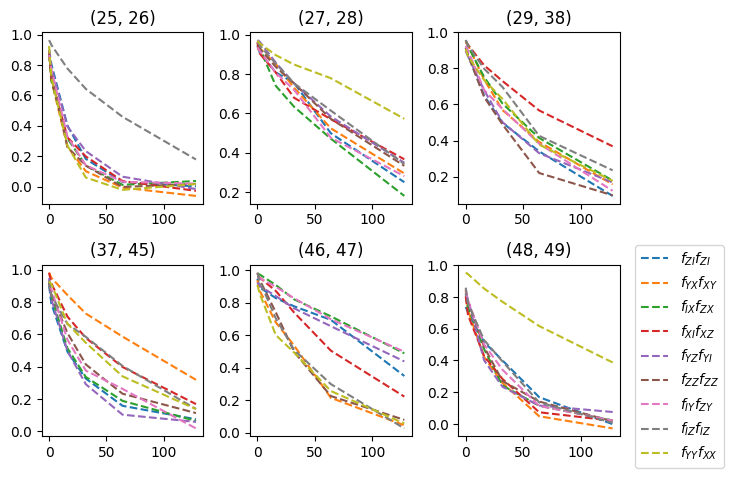

In [13]:
from matplotlib import pyplot as plt

from qiskit_noise_learning.analysis import AverageObservables

# compute observables and plot empirical decays

averaged_data = AverageObservables().run(fit).averaged_data


def _sorted_data(averaged_data):
    dataset = averaged_data.dataset

    sorted_data = {}
    for path_pattern, depth, val in zip(
        dataset["path_pattern"].data, dataset["depth"].data, dataset["observables"].data
    ):
        if depth < 0:
            continue
        this_data = sorted_data.setdefault(path_pattern, ([], []))
        this_data[0].append(val)
        this_data[1].append(depth)

    return {k: v for k, v in sorted_data.items() if len(v[0]) > 1}  # filter on decays


def plot(averaged_data, subsets, num_cols=3):
    sorted_data = _sorted_data(averaged_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for path_pattern in sorted_data.keys():
            if set(subset).issuperset(path_pattern.start_fragment[0].out_bit_indices):
                plots[subset].append(path_pattern)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    for ax, (subset, path_patterns) in zip(axs.flat, plots.items()):
        ax.set_title(f"{subset}")
        for path_pattern in path_patterns:
            this_data = sorted_data[path_pattern]
            label = fidelity_label(path_pattern, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                "--",
                label=label,
            )
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


def fidelity_label(path_pattern, subset):
    return (
        "$f_{"
        + "} f_{".join(
            "".join(str(fid.pauli.to_pauli()[subset])) for fid in path_pattern.repeatable_fragment
        )
        + "} $"
    )


plot(averaged_data, layer_1_pairs)

In [14]:
model_data = fit.model_data
noise_maps = pauli_lindblad_model.to_pauli_lindblad_maps(model_data)

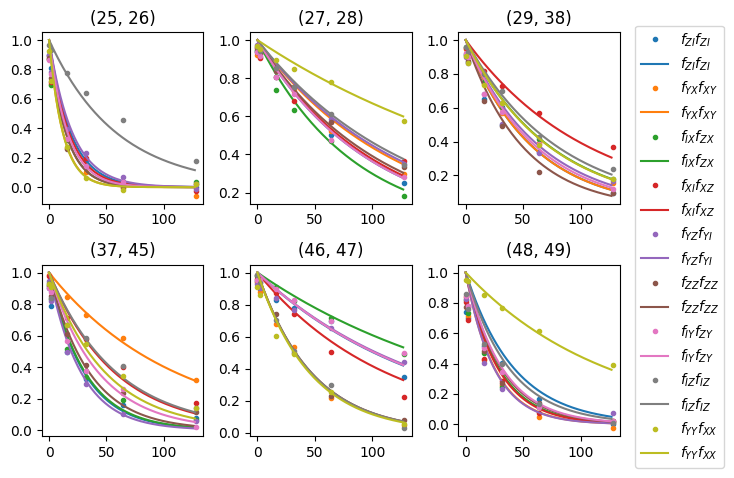

In [15]:
# plot decays v.s. model prediction
# Note: plotting model decays without prefactors from SPAM
import matplotlib.colors as mcolors
import numpy as np


def plot_with_model_decay(
    pauli_lindblad_map, observable_data, subsets, num_cols=3, start_idx=None, end_idx=None
):
    sorted_data = _sorted_data(observable_data)

    plots = {}
    for subset in subsets:
        plots[subset] = []
        for path_pattern in sorted_data.keys():
            if set(subset).issuperset(path_pattern.start_fragment[0].out_bit_indices):
                plots[subset].append(path_pattern)

    num_figs = len(plots)
    num_rows = num_figs // num_cols

    fig, axs = plt.subplots(num_rows, num_cols)
    flag = True
    for ax, (subset, path_patterns) in zip(axs.flat, plots.items()):
        ax.set_title(f"{subset}")
        if start_idx is None:
            start_idx = 0
        if end_idx is None:
            end_idx = len(path_patterns)
        for color_code, path_pattern in list(zip(mcolors.TABLEAU_COLORS.values(), path_patterns))[
            start_idx:end_idx
        ]:
            this_data = sorted_data[path_pattern]
            label = fidelity_label(path_pattern, [s for s in subset]) if flag else None
            ax.plot(
                this_data[1],
                this_data[0],
                ".",
                label=label,
                color=color_code,
            )
            pauli_in = path_pattern.repeatable_fragment[0].transition[0]
            fidelity_in = pauli_lindblad_map.pauli_fidelity(pauli_in)
            pauli_out = path_pattern.repeatable_fragment[0].transition[1]
            fidelity_out = pauli_lindblad_map.pauli_fidelity(pauli_out)
            ax.plot(
                np.arange(max(this_data[1])),
                (fidelity_in * fidelity_out) ** (np.arange(max(this_data[1]))),
                "-",
                label=label,
                color=color_code,
            )
        flag = False

    fig.legend(bbox_to_anchor=(1.15, 0), loc="lower right")
    plt.tight_layout()


# k = 8
plot_with_model_decay(
    noise_maps["layer_1"], averaged_data, layer_1_pairs
)  # , start_idx=k, end_idx=k + 1)

## 7. Investigating results

### 7.1 Comparison to `NoiseLearnerV3`

In [16]:
from qiskit.circuit import BoxOp, CircuitInstruction, QuantumRegister, Qubit
from qiskit_ibm_runtime.noise_learner_v3.noise_learner_v3 import (
    NoiseLearnerV3,
    NoiseLearnerV3Options,
)
from samplomatic.annotations import Twirl

options = NoiseLearnerV3Options(
    shots_per_randomization=num_shots, num_randomizations=num_rand, layer_pair_depths=depths
)

noise_learner = NoiseLearnerV3(mode=backend, options=options)

gate = gate_set["layer_1"]
qreg = QuantumRegister(backend.target.num_qubits, "q")
circuit_instruction = CircuitInstruction(
    BoxOp(gate.circuit, annotations=[Twirl()]),
    [Qubit(register=qreg, index=x) for x in gate.qubit_idxs],
)

# job = noise_learner.run([circuit_instruction])
job = runtime.job("d7h96gq2khts739pftf0")
result = job.result()

# map onto qubit subset (noise learner returns map with virtual indices)
# confused about indices...
noise_learner_map = (
    result[0].to_pauli_lindblad_map().apply_layout(sorted(gate.qubit_idxs), num_qubits=156)
)

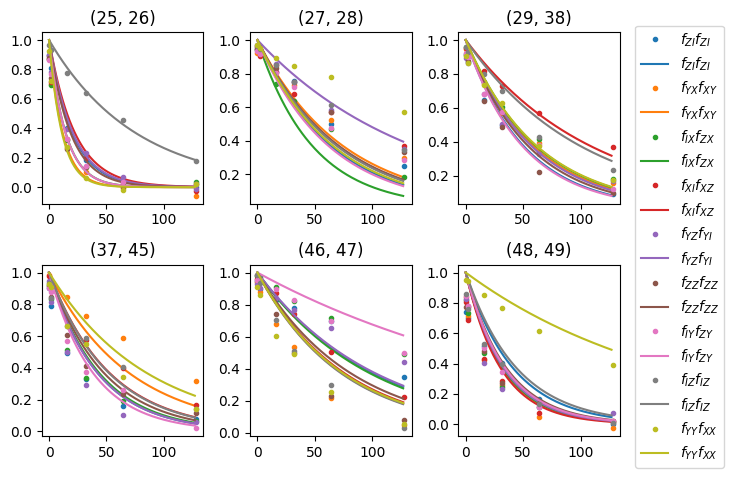

In [17]:
plot_with_model_decay(noise_learner_map, averaged_data, layer_1_pairs)